In [1]:
import duckdb
import os

In [2]:
# connecting to db
con = duckdb.connect()

In [3]:
BASE_DIR = "/mnt/c/SJSU/Spring 2026/DATA 298A/02 Sample Data/UWF_Data"
PARQUET_FILE = "/mnt/c/SJSU/Spring 2026/DATA 298A/02 Sample Data/UWF_Data/combined_uwf_dataset.parquet"
DB_FILE = os.path.join(BASE_DIR, "uwf_cybersecurity.db")

In [35]:
# Creating table with schema from paraquet file
con.execute("""
CREATE TABLE network_logs (
    resp_pkts BIGINT,           -- 0
    service VARCHAR,            -- 1
    orig_ip_bytes BIGINT,       -- 2
    local_resp BOOLEAN,         -- 3
    missed_bytes BIGINT,        -- 4
    proto VARCHAR,              -- 5
    duration DOUBLE,            -- 6
    conn_state VARCHAR,         -- 7
    dest_ip_zeek VARCHAR,       -- 8
    orig_pkts BIGINT,           -- 9
    community_id VARCHAR,       -- 10
    resp_ip_bytes BIGINT,       -- 11
    dest_port_zeek INTEGER,     -- 12
    orig_bytes BIGINT,          -- 13
    local_orig BOOLEAN,         -- 14
    datetime TIMESTAMP,         -- 15 
    history VARCHAR,            -- 16
    resp_bytes BIGINT,          -- 17
    uid VARCHAR,                -- 18
    src_port_zeek INTEGER,      -- 19
    ts DOUBLE,                  -- 20
    src_ip_zeek VARCHAR,        -- 21
    label_tactic VARCHAR,       -- 22
    source_period VARCHAR,      -- 23
    label_technique VARCHAR,    -- 24
    label_cve VARCHAR,          -- 25
    label_binary VARCHAR,       -- 26
    vlan VARCHAR                -- 27
);
""")
print("Table schema created successfully.")

Table schema created successfully.


In [36]:
con.execute(f"INSERT INTO network_logs SELECT * FROM read_parquet('{PARQUET_FILE}')")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [34]:
# con.execute("DROP TABLE IF EXISTS network_logs")

In [37]:
# First few rows
con.execute("SELECT * FROM network_logs LIMIT 5").df()

,resp_pkts,service,orig_ip_bytes,local_resp,missed_bytes,proto,duration,conn_state,dest_ip_zeek,orig_pkts,...,uid,src_port_zeek,ts,src_ip_zeek,label_tactic,source_period,label_technique,label_cve,label_binary,vlan
0,1689365,NaN,141906660,False,0,icmp,1.729902e+06,OTH,143.88.0.1,1689365,...,Caxllt2aEzXOEZnpii,8,1.639746e+09,143.88.255.50,none,2021-12-12%20-%202021-12-19,unknown,unknown,unknown,unknown
1,0,NaN,462247452,False,0,icmp,1.730391e+06,OTH,143.88.255.10,4576716,...,CEx0rX1Yic8axI4sw1,3,1.639746e+09,143.88.255.1,none,2021-12-12%20-%202021-12-19,unknown,unknown,unknown,unknown
2,0,NaN,22008480,False,0,icmp,1.730410e+06,OTH,ff02::1,229255,...,Cpn5bT1QW9MPFXikn4,134,1.639746e+09,fe80::250:56ff:fe9e:da15,none,2021-12-12%20-%202021-12-19,unknown,unknown,unknown,unknown
3,0,NaN,34970488,False,0,icmp,1.730411e+06,OTH,ff02::16,460138,...,Ceo6B73UmSZVe8vsD4,143,1.639746e+09,fe80::250:56ff:fe9e:ef90,none,2021-12-12%20-%202021-12-19,unknown,unknown,unknown,unknown
4,0,dhcp,66459795,False,0,udp,1.731504e+06,S0,255.255.255.255,202621,...,CTCPKc2faq2rLYJA4f,68,1.639746e+09,0.0.0.0,none,2021-12-12%20-%202021-12-19,unknown,unknown,unknown,unknown


In [44]:
# shape of data

con.execute("SELECT COUNT(*) FROM network_logs").fetchone()[0]

27111594

**27M rows**

In [39]:
# columns

con.execute("""SELECT column_name
FROM information_schema.columns
WHERE table_name = 'network_logs'""").df()

,column_name
0,resp_pkts
1,service
2,orig_ip_bytes
3,local_resp
4,missed_bytes
5,proto
6,duration
7,conn_state
8,dest_ip_zeek
9,orig_pkts


#### Exploring target variables

In [40]:
# unique label_binary
con.execute("""
SELECT DISTINCT label_binary FROM network_logs
""").df()

,label_binary
0,True
1,False
2,Duplicate
3,unknown


**True - means its an attack and False is normal event**

**unknown is for data that didn't originally have this column. Duplicate needs to be removed**

**label_tactic is consistently present in all datasets... so using that to label label_binary is normal when label_tatcis is none and it is attack when there is label_tactic**

In [45]:
# creating new table after removing duplicates

con.execute("""
    CREATE OR REPLACE TABLE network_logs_clean AS 
    SELECT * FROM network_logs 
    WHERE label_binary != 'Duplicate'
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [46]:
con.execute("SELECT COUNT(*) FROM network_logs_clean").fetchone()[0]

27078541

In [47]:
con.execute("""
SELECT DISTINCT label_binary FROM network_logs_clean
""").df()

,label_binary
0,True
1,False
2,unknown


handling unknown using label_tactic column

In [48]:
# adding column for clean target

con.execute("ALTER TABLE network_logs_clean ADD COLUMN IF NOT EXISTS final_target VARCHAR;")

In [49]:
con.execute("""
    UPDATE network_logs_clean SET final_target = 
    CASE 
        WHEN label_tactic != 'none' AND label_tactic IS NOT NULL THEN 'Attack'
        ELSE 'Normal'
    END
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [51]:
con.execute("""
SELECT DISTINCT final_target FROM network_logs_clean
""").df()

,final_target
0,Normal
1,Attack


**Final_target is the actual target to use further**

In [53]:
con.execute("""
SELECT DISTINCT label_tactic FROM network_logs_clean
""").df()

,label_tactic
0,Persistence
1,Discovery
2,Execution
3,Collection
4,Credential Access
5,Defense Evasion
6,Initial Access
7,none
8,Lateral Movement
9,Privilege Escalation


In [55]:
con.execute("""

SELECT DISTINCT (label_tactic), final_target
FROM network_logs_clean
WHERE label_tactic = 'none'

""").df()

,label_tactic,final_target
0,none,Normal


**based on this label_tactic is none means its a normal event**

In [56]:
con.execute("""

SELECT DISTINCT(label_technique)
FROM network_logs_clean
""").df()

,label_technique
0,T1547
1,T1204
2,T1133
3,T1557
4,T1589
5,T1592
6,T1071
7,T1505
8,T1546
9,T1210


In [57]:
con.execute("""

SELECT DISTINCT (label_technique), final_target
FROM network_logs_clean
WHERE label_technique = 'unknown'

""").df()

,label_technique,final_target
0,unknown,Normal
1,unknown,Attack


In [59]:
# updating label technique , when its normal event, the technique should be none

con.execute("""
    UPDATE network_logs_clean SET 
        label_technique = CASE 
            WHEN final_target = 'Normal' THEN 'none'
            ELSE label_technique
        END
""")

In [60]:
con.execute("""

SELECT DISTINCT (label_technique), final_target
FROM network_logs_clean
WHERE label_technique = 'unknown'

""").df()

,label_technique,final_target
0,unknown,Attack


In [61]:
con.execute("""
SELECT DISTINCT label_tactic, label_technique
FROM network_logs_clean
ORDER BY label_tactic, label_technique;

""").df()

,label_tactic,label_technique
0,Collection,T1557
1,Command and Control,T1071
2,Command and Control,T1571
3,Credential Access,T1110
4,Credential Access,unknown
5,Defense Evasion,T1078
6,Defense Evasion,T1112
7,Defense Evasion,T1548
8,Defense Evasion,unknown
9,Discovery,T1016


In [62]:
# Replacing 'unknown' with '{Tactic}_unspecified'

con.execute("""
    UPDATE network_logs_clean SET 
        label_technique = CASE 
            WHEN label_technique = 'unknown' AND label_tactic != 'none' 
                THEN label_tactic || '_unspecified'
            ELSE label_technique
        END
""")

In [63]:
con.execute("""
    SELECT DISTINCT label_tactic, label_technique 
    FROM network_logs_clean 
    WHERE label_technique LIKE '%_unspecified'
""").df()

,label_tactic,label_technique
0,Discovery,Discovery_unspecified
1,Exfiltration,Exfiltration_unspecified
2,Lateral Movement,Lateral Movement_unspecified
3,Credential Access,Credential Access_unspecified
4,Defense Evasion,Defense Evasion_unspecified
5,Persistence,Persistence_unspecified
6,Resource Development,Resource Development_unspecified
7,Initial Access,Initial Access_unspecified
8,Privilege Escalation,Privilege Escalation_unspecified
9,Reconnaissance,Reconnaissance_unspecified


In [64]:
con.execute("""
SELECT DISTINCT label_tactic, label_technique
FROM network_logs_clean
ORDER BY label_tactic, label_technique;

""").df()

,label_tactic,label_technique
0,Collection,T1557
1,Command and Control,T1071
2,Command and Control,T1571
3,Credential Access,Credential Access_unspecified
4,Credential Access,T1110
5,Defense Evasion,Defense Evasion_unspecified
6,Defense Evasion,T1078
7,Defense Evasion,T1112
8,Defense Evasion,T1548
9,Discovery,Discovery_unspecified


**mapping unknown techniques to their parent tactics instead of leaving them blank, we preserved the adversarial context for older data.**

**As we don't have granular sub-type for that specific year, preserving facts without hallucinating using some T-ID**

In [67]:
# analyzing label_cve

con.execute("""
SELECT DISTINCT label_cve
FROM network_logs_clean
""").df()


,label_cve
0,none
1,unknown


**Dropping cve column, as it doesnt have any info**

In [68]:
con.execute("ALTER TABLE network_logs_clean DROP COLUMN label_cve;")

In [69]:
con.execute("DESCRIBE network_logs_clean").df()

,column_name,column_type,null,key,default,extra
0,resp_pkts,BIGINT,YES,None,None,None
1,service,VARCHAR,YES,None,None,None
2,orig_ip_bytes,BIGINT,YES,None,None,None
3,local_resp,BOOLEAN,YES,None,None,None
4,missed_bytes,BIGINT,YES,None,None,None
5,proto,VARCHAR,YES,None,None,None
6,duration,DOUBLE,YES,None,None,None
7,conn_state,VARCHAR,YES,None,None,None
8,dest_ip_zeek,VARCHAR,YES,None,None,None
9,orig_pkts,BIGINT,YES,None,None,None


In [70]:
# checking for missing values

# 1. Get the names of all columns currently in the table
columns_info = con.execute("DESCRIBE network_logs_clean").df()
columns = columns_info['column_name'].tolist()

# 2. Build a dynamic query to count NULLs for every column
# (COUNT(*) - COUNT(col)) gives the number of missing values
null_queries = ", ".join([f"COUNT(*) - COUNT({col}) AS {col}" for col in columns])
final_query = f"SELECT {null_queries} FROM network_logs_clean"

# 3. Execute and format the results
null_counts = con.execute(final_query).df().T
null_counts.columns = ['null_count']

# 4. Add a percentage column for easier reporting
total_rows = con.execute("SELECT COUNT(*) FROM network_logs_clean").fetchone()[0]
null_counts['null_percentage'] = (null_counts['null_count'] / total_rows) * 100

print(f"Total Unique Rows analyzed: {total_rows}")
print("\n--- Missing Values Audit (Sorted by highest nulls) ---")
print(null_counts.sort_values(by='null_count', ascending=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total Unique Rows analyzed: 27078541

--- Missing Values Audit (Sorted by highest nulls) ---
                 null_count  null_percentage
service            12236489        45.188879
duration            2873552        10.611916
resp_bytes          2873552        10.611916
orig_bytes          2873552        10.611916
vlan                 157331         0.581017
history               87000         0.321288
proto                     0         0.000000
conn_state                0         0.000000
local_resp                0         0.000000
missed_bytes              0         0.000000
orig_ip_bytes             0         0.000000
resp_pkts                 0         0.000000
resp_ip_bytes             0         0.000000
community_id              0         0.000000
orig_pkts                 0         0.000000
dest_ip_zeek              0         0.000000
datetime                  0         0.000000
local_orig                0         0.000000
uid                       0         0.000000
dest_po

In [74]:
con.execute("""
SELECT DISTINCT history FROM network_logs_clean

""").df()

,history
0,SAhDadfFR
1,ShADagdFf
2,ShADadfGF
3,ShAaGdfDF
4,SAhDadFR
...,...
1771,ShADadttTTFrr
1772,ShAdGDFaf
1773,ShADTadttgTFf
1774,ShADTadtFR


**History contains values that means this => S (SYN) and ShA (SYN, SYN-ACK, ACK)**

In [77]:
# filling null values in history with a placeholder

con.execute("UPDATE network_logs_clean SET history = COALESCE(history, '-')")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [78]:
con.execute("""
    SELECT history, final_target, COUNT(*) as count
    FROM network_logs_clean
    GROUP BY history, final_target
    ORDER BY count DESC
    LIMIT 10
""").df()

,history,final_target,count
0,D,Normal,10414602
1,S,Attack,7909023
2,Sr,Attack,3384518
3,Dd,Normal,2342953
4,ShADTdttFaf,Attack,847575
5,^d,Normal,361115
6,Dd,Attack,240086
7,S,Normal,178589
8,^d,Attack,177669
9,D,Attack,136304


In [79]:
con.execute("""
SELECT DISTINCT vlan FROM network_logs_clean 

""").df()

,vlan
0,105.0
1,9.0
2,7.0
3,103
4,110
5,11.0
6,111.0
7,109.0
8,NaN
9,110.0


In [80]:
# 1. Standardize VLAN: Convert to string, remove '.0', and handle 'unknown'/'NaN'
con.execute("""
    UPDATE network_logs_clean SET 
        vlan = CASE 
            WHEN vlan IS NULL OR vlan = 'unknown' OR vlan = 'NaN' THEN 'none'
            ELSE CAST(CAST(vlan AS FLOAT) AS INTEGER)::VARCHAR
        END
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [81]:
con.execute("SELECT DISTINCT vlan FROM network_logs_clean ORDER BY vlan").df()

,vlan
0,1
1,10
2,101
3,102
4,103
5,104
6,105
7,106
8,107
9,108


In [82]:
# handling remaining missing values
# Filling numerical and categorical gaps
con.execute("""
    UPDATE network_logs_clean SET 
        service = COALESCE(service, 'unknown'),
        duration = COALESCE(duration, 0),
        orig_bytes = COALESCE(orig_bytes, 0),
        resp_bytes = COALESCE(resp_bytes, 0)
""")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [83]:
# checking for missing values

# 1. Get the names of all columns currently in the table
columns_info = con.execute("DESCRIBE network_logs_clean").df()
columns = columns_info['column_name'].tolist()

# 2. Build a dynamic query to count NULLs for every column
# (COUNT(*) - COUNT(col)) gives the number of missing values
null_queries = ", ".join([f"COUNT(*) - COUNT({col}) AS {col}" for col in columns])
final_query = f"SELECT {null_queries} FROM network_logs_clean"

# 3. Execute and format the results
null_counts = con.execute(final_query).df().T
null_counts.columns = ['null_count']

# 4. Add a percentage column for easier reporting
total_rows = con.execute("SELECT COUNT(*) FROM network_logs_clean").fetchone()[0]
null_counts['null_percentage'] = (null_counts['null_count'] / total_rows) * 100

print(f"Total Unique Rows analyzed: {total_rows}")
print("\n--- Missing Values Audit (Sorted by highest nulls) ---")
print(null_counts.sort_values(by='null_count', ascending=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total Unique Rows analyzed: 27078541

--- Missing Values Audit (Sorted by highest nulls) ---
                 null_count  null_percentage
resp_pkts                 0              0.0
service                   0              0.0
orig_ip_bytes             0              0.0
local_resp                0              0.0
missed_bytes              0              0.0
proto                     0              0.0
duration                  0              0.0
conn_state                0              0.0
dest_ip_zeek              0              0.0
orig_pkts                 0              0.0
community_id              0              0.0
resp_ip_bytes             0              0.0
dest_port_zeek            0              0.0
orig_bytes                0              0.0
local_orig                0              0.0
datetime                  0              0.0
history                   0              0.0
resp_bytes                0              0.0
uid                       0              0.0
src_por

In [85]:
## total count of unique IP addresses across both source and destination

con.execute(
"""
SELECT COUNT(DISTINCT ip) as total_unique_nodes
FROM (
    SELECT src_ip_zeek AS ip FROM network_logs_clean
    UNION
    SELECT dest_ip_zeek AS ip FROM network_logs_clean
)
"""
).fetchone()[0]

1176

**The network has a small number of devices (1,176 IPs) but a very large number of connections between them (over 27 million), which means the network is very dense and highly connected.**

**Each device has lots of connection data, the GNN can learn strong patterns easily, and since there aren’t many devices, the model can be trained all at once without needing complex sampling methods.**

In [86]:
#Most active pair of IP's

con.execute("""
    SELECT src_ip_zeek, dest_ip_zeek, COUNT(*) as connection_count
    FROM network_logs_clean
    GROUP BY src_ip_zeek, dest_ip_zeek
    ORDER BY connection_count DESC
    LIMIT 10
""").df()

,src_ip_zeek,dest_ip_zeek,connection_count
0,143.88.255.10,10.0.10.1,6999813
1,143.88.2.10,143.88.7.11,3112192
2,143.88.2.10,143.88.7.1,2093056
3,143.88.2.10,143.88.7.15,1661440
4,143.88.2.10,143.88.7.12,1125888
5,143.88.7.10,143.88.2.10,521472
6,143.88.5.12,143.88.5.1,503442
7,143.88.11.14,143.88.11.1,494889
8,143.88.11.10,8.8.8.8,462862
9,143.88.11.10,8.8.4.4,461316


**A small number of devices handle most of the 27 million connections, with some pairs communicating millions of times. This shows the network follows a “hub-and-spoke” pattern.
These highly connected devices are very important, so the GNN should focus more on them, since if they are attacked, it could lead to bigger security risks like spreading attacks or data theft.**

In [88]:
# # 1. Creating the encoded table with Log Scaling and One-Hot Encoding
con.execute("""
CREATE OR REPLACE TABLE network_logs_encoded AS
SELECT 
    -- IDs (Keep for mapping)
    src_ip_zeek,
    dest_ip_zeek,
    
    -- 1. Log Scaling for Numerical Features
    ln(1 + duration) as log_duration,
    ln(1 + orig_bytes) as log_orig_bytes,
    ln(1 + resp_bytes) as log_resp_bytes,
    ln(1 + orig_pkts) as log_orig_pkts,
    ln(1 + resp_pkts) as log_resp_pkts,
    
    -- 2. One-Hot Encoding: Protocol (Commonly 3 values)
    CASE WHEN proto = 'tcp' THEN 1 ELSE 0 END as proto_tcp,
    CASE WHEN proto = 'udp' THEN 1 ELSE 0 END as proto_udp,
    CASE WHEN proto = 'icmp' THEN 1 ELSE 0 END as proto_icmp,
    
    -- 3. Top-K Encoding: Service (Encoding top 5, others as 0)
    CASE WHEN service = 'http' THEN 1 ELSE 0 END as srv_http,
    CASE WHEN service = 'dns' THEN 1 ELSE 0 END as srv_dns,
    CASE WHEN service = 'ssl' THEN 1 ELSE 0 END as srv_ssl,
    CASE WHEN service = 'ssh' THEN 1 ELSE 0 END as srv_ssh,
    CASE WHEN service = 'unknown' THEN 1 ELSE 0 END as srv_unknown,
    
    -- 4. Target (Label)
    CASE WHEN final_target = 'Attack' THEN 1 ELSE 0 END as label
FROM network_logs_clean
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [89]:
con.execute("SELECT * FROM network_logs_encoded LIMIT 5").df()

,src_ip_zeek,dest_ip_zeek,log_duration,log_orig_bytes,log_resp_bytes,log_orig_pkts,log_resp_pkts,proto_tcp,proto_udp,proto_icmp,srv_http,srv_dns,srv_ssl,srv_ssh,srv_unknown,label
0,143.88.255.50,143.88.0.1,14.363576,18.365215,18.365215,14.339864,14.339864,0,0,1,0,0,0,0,1,0
1,143.88.255.1,143.88.255.10,14.363858,19.626949,0.000000,15.336492,0.000000,0,0,1,0,0,0,0,1,0
2,fe80::250:56ff:fe9e:da15,ff02::1,14.363870,16.213791,0.000000,12.342595,0.000000,0,0,1,0,0,0,0,1,0
3,fe80::250:56ff:fe9e:ef90,ff02::16,14.363870,16.035014,0.000000,13.039284,0.000000,0,0,1,0,0,0,0,1,0
4,0.0.0.0,255.255.255.255,14.364501,17.922877,0.000000,12.219097,0.000000,0,1,0,0,0,0,0,0,0


**Large values (like very big data transfers) were scaled down using a log function so they don’t overpower smaller values, and only the most important categories (like key services and protocols) were converted into numerical form using one-hot encoding.
This helps the model learn better because it reduces the effect of extreme values, keeps the data simple and efficient, and makes sure all information is in a format the GNN can understand.**

In [90]:
# 1176 ID's are present.Extracting every unique IP from both the source and destination columns and assign them a unique ID from 0 to 1175

# Creating a table of all unique IPs and assign a Row ID (the Index)
con.execute("""
CREATE OR REPLACE TABLE node_mapping AS
SELECT 
    ip, 
    (ROW_NUMBER() OVER (ORDER BY ip)) - 1 as node_id
FROM (
    SELECT src_ip_zeek AS ip FROM network_logs_encoded
    UNION
    SELECT dest_ip_zeek AS ip FROM network_logs_encoded
) AS unique_ips
""")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [91]:
con.execute("SELECT * FROM node_mapping LIMIT 5").df()

,ip,node_id
0,0.0.0.0,0
1,1.1.1.1,1
2,10.0.10.1,2
3,127.0.0.1,3
4,128.250.36.3,4


In [92]:
con.execute("SELECT COUNT(*) FROM node_mapping").fetchone()[0]

1176

In [93]:
# Generating edge index
# Create a finalized table for GNN training
con.execute("""
CREATE OR REPLACE TABLE gnn_ready_data AS
SELECT 
    s.node_id as source_idx,
    d.node_id as target_idx,
    e.* EXCLUDE (src_ip_zeek, dest_ip_zeek) -- Keep all our log-scaled and encoded features
FROM network_logs_encoded e
JOIN node_mapping s ON e.src_ip_zeek = s.ip
JOIN node_mapping d ON e.dest_ip_zeek = d.ip
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [94]:
con.execute("SELECT source_idx, target_idx, log_duration, label FROM gnn_ready_data LIMIT 5").df()

,source_idx,target_idx,log_duration,label
0,456,2,0.000013,0
1,456,2,0.000017,0
2,456,2,0.000011,0
3,456,2,0.000012,0
4,456,2,0.000013,0


**Each IP address was given a unique number (from 0 to 1175), and the network connections were converted into a format that GNN tools can easily use.
This makes the model run faster and avoids errors, because GNNs work best with numbered nodes and a well-structured graph format.**

In [87]:
# summary of edges

con.execute("""
    CREATE OR REPLACE TABLE graph_edges AS
    SELECT 
        src_ip_zeek, 
        dest_ip_zeek, 
        COUNT(*) as edge_weight,
        AVG(duration) as avg_duration,
        AVG(orig_bytes) as avg_orig_bytes,
        AVG(resp_bytes) as avg_resp_bytes,
        -- If any connection in this pair was an attack, we'll mark the edge
        MAX(CASE WHEN final_target = 'Attack' THEN 1 ELSE 0 END) as contains_attack
    FROM network_logs_clean
    GROUP BY src_ip_zeek, dest_ip_zeek
""").fetchone()[0]

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2183

In [95]:
# edge attribute aggregaion
con.execute("""
CREATE OR REPLACE TABLE gnn_edge_attr AS
SELECT 
    source_idx,
    target_idx,
    -- 1. Structural Feature: How many times did they talk?
    ln(1 + COUNT(*)) as edge_weight,
    
    -- 2. Behavioral Features: Average of our log-scaled values
    AVG(log_duration) as avg_log_duration,
    AVG(log_orig_bytes) as avg_log_orig_bytes,
    AVG(log_resp_bytes) as avg_log_resp_bytes,
    
    -- 3. Protocol Features: Sum of protocol flags (shows intensity)
    SUM(proto_tcp) as total_tcp,
    SUM(proto_udp) as total_udp,
    SUM(srv_http) as total_http,
    SUM(srv_dns) as total_dns,
    
    -- 4. Final Label: Max is 1 if any attack occurred
    MAX(label) as is_attack_edge
FROM gnn_ready_data
GROUP BY source_idx, target_idx
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [96]:
con.execute("SELECT COUNT(*) FROM gnn_edge_attr").fetchone()[0]

2183

#### Pytorch Geometric data bridge

In [98]:
# !pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 41.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.4/242.4 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.3/256.3 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.6/221.6 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 kB 7.0 MB/s eta 0:00:00


In [100]:
import torch
from torch_geometric.data import Data
import pandas as pd

In [101]:
# Load Edge Attributes and Indices
df_edges = con.execute("SELECT * FROM gnn_edge_attr").df()

In [102]:
# 2. Prepare Edge Index [2, E]
# PyG expects a long tensor of [source_nodes, target_nodes]
edge_index = torch.tensor(df_edges[['source_idx', 'target_idx']].values.T, dtype=torch.long)

In [103]:
# 3. Prepare Edge Attributes [E, num_features]
# We exclude the indices and the label itself
edge_features = df_edges.drop(columns=['source_idx', 'target_idx', 'is_attack_edge'])
edge_attr = torch.tensor(edge_features.values, dtype=torch.float)

In [104]:
# 4. Prepare Labels (y)
y = torch.tensor(df_edges['is_attack_edge'].values, dtype=torch.long)

In [105]:
# 5. node features
num_nodes = 1176
x = torch.eye(num_nodes)

In [106]:
# 6. Construct the PyG Data Object
data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

In [107]:
print(data)
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Number of edge features: {data.num_edge_features}")

Data(x=[1176, 1176], edge_index=[2, 2183], edge_attr=[2183, 8], y=[2183])
Number of nodes: 1176
Number of edges: 2183
Number of edge features: 8


#### Visualizing the Graph

In [109]:
# !pip install matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 47.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 56.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 48.1 MB/s eta 0:00:00


In [111]:
# !pip install scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 45.0 MB/s eta 0:00:0000:0100:01


Computing layout... this may take a minute.


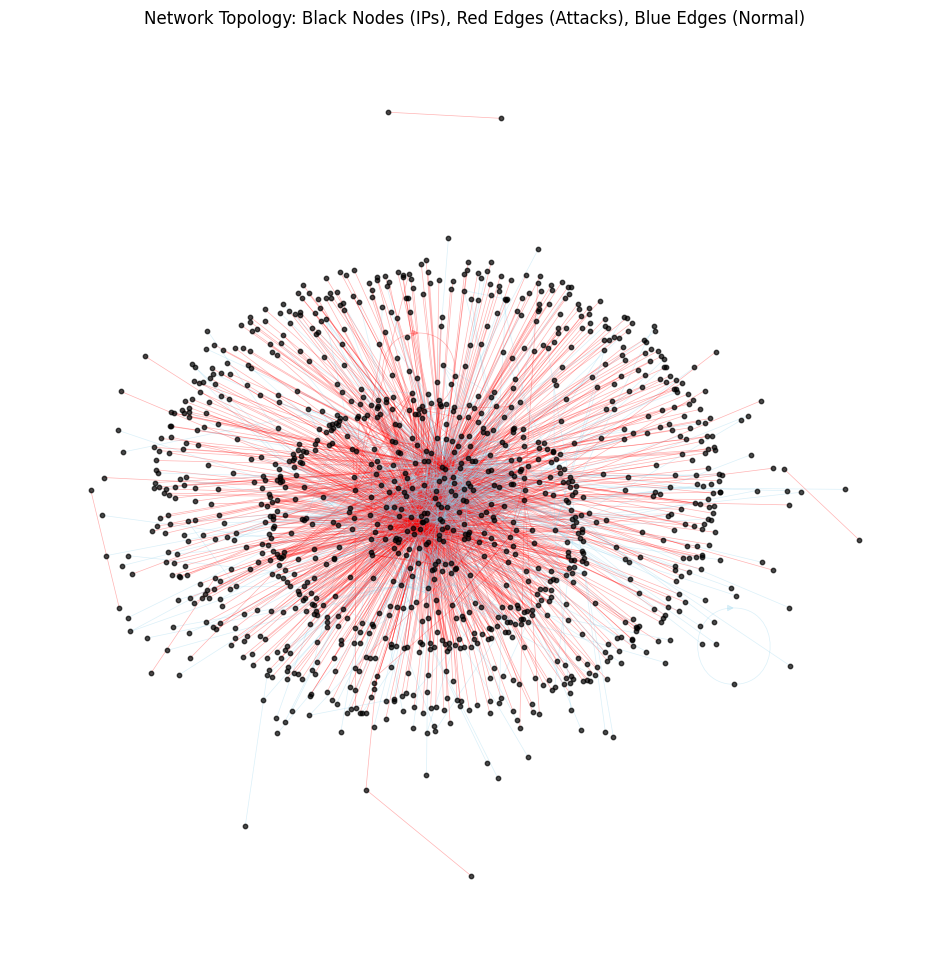

In [112]:
import networkx as nx
import matplotlib.pyplot as plt


# 1. Convert PyG data to NetworkX
# using directed graph
G = nx.DiGraph()

# Add edges and their labels
edge_index = data.edge_index.numpy()
edge_labels = data.y.numpy()

for i in range(edge_index.shape[1]):
    src = edge_index[0, i]
    dst = edge_index[1, i]
    is_attack = edge_labels[i]
    G.add_edge(src, dst, attack=is_attack)

# 2. Define Layout (Force-directed)
print("Computing layout... this may take a minute.")
pos = nx.spring_layout(G, k=0.15, iterations=20)

# 3. Define Colors
# Red for attacks, SkyBlue for normal traffic
edge_colors = ['red' if G[u][v]['attack'] == 1 else 'skyblue' for u, v in G.edges()]
edge_alphas = [0.8 if G[u][v]['attack'] == 1 else 0.2 for u, v in G.edges()]

# 4. Draw the Graph
plt.figure(figsize=(12, 12))
nx.draw_networkx_nodes(G, pos, node_size=10, node_color='black', alpha=0.7)
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, alpha=0.3, arrows=False, width=0.5)

plt.title("Network Topology: Black Nodes (IPs), Red Edges (Attacks), Blue Edges (Normal)")
plt.axis('off')
plt.show()

**The center of the graph is very crowded, showing that most devices are heavily connected and constantly communicating, which is normal for a working network like a data center.
The nodes far away from the center have very few connections, making them stand out. These could be unusual or suspicious devices, so they are important to pay attention to.**

In [123]:
# saving graph to disk

# torch.save(data, 'uwf_gnn_data_ready.pt')

# SUMMARY


### **EDA (Exploratory Data Analysis)**
* **Dataset Auditing:** Verified a total of 27,111,594 log entries from the Parquet source.
* **Label Distribution:** Identified three label columns (`label_binary`, `label_tactic`, `label_score`); found `label_binary` had inconsistent "Unknown" and "Duplicate" entries.
* **Duplicate Analysis:** Discovered ~33,000 redundant rows that were non-informative for the model.
* **Class Imbalance Check:** Confirmed "Attack" samples are significantly rarer than "Normal" traffic, requiring weighted training later.
* **Connectivity Audit:** Found that despite 27M logs, there are only 1,176 unique IP addresses (nodes) and 2,183 unique communication pairs (edges).
* **Topology Visualization:** Created a force-directed graph revealing a highly dense "core" of production traffic and isolated peripheral nodes.
    * **Insight:** The network is small but extremely "chatty," meaning each edge has a very rich behavioral history.

### **Data Cleaning**
* **Redundancy Removal:** Dropped the ~33k "Duplicate" rows identified during EDA.
* **Target Standardization:** Created a new `final_target` column by mapping any non-null `label_tactic` as an "Attack" (1) and 'none' as "Normal" (0).
* **Null Handling:** Sanitized categorical fields to ensure no `NULL` values would break the GNN training.

### **Data Transformation**
* **Numerical Scaling:** Applied Log Transformation ($ln(1+x)$) to `duration`, `orig_bytes`, and `resp_bytes`.
    * **Insight:** This prevents massive traffic spikes from over-powering the neural network's learning process.
* **Categorical Encoding:** Converted `proto` (TCP/UDP/ICMP) and the Top-5 `service` types into binary (One-Hot) columns.
* **Feature Aggregation:** Compressed 27M logs into 2,183 unique edges using `GROUP BY`.
    * **Insight:** Each edge now contains the *average* behavior (mean bytes, mean duration) and *total* activity (count) of that connection.

### **Data Preparation**
* **Node Mapping:** Built a dictionary mapping 1,176 unique IP strings to integer IDs ($0$ to $1175$).
* **Adjacency List Construction:** Generated the `edge_index` tensor representing "Source $\rightarrow$ Target" relationships.
* **Feature Tensorization:** Converted the aggregated DuckDB tables into PyTorch Tensors (`x`, `edge_index`, `edge_attr`, and `y`).
* **Graph Object Creation:** Consolidated all tensors into a single PyTorch Geometric `Data` object for the model.
* **Data Split:** Implemented an 80/20 train-test mask on the edges to ensure valid performance evaluation.